In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

cwd = Path.cwd()

if (cwd / "evals").exists():
    evals_dir = cwd / "evals"
else:
    evals_dir = cwd.parent

results_dir = evals_dir / "results"
plots_dir = evals_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

baseline_path = results_dir / "baseline_no_reranker.csv"
reranker_path = results_dir / "local_onnx_reranker.csv"

print("Current working directory:", cwd)
print("Results directory:", results_dir)
print("Baseline exists:", baseline_path.exists())
print("Reranker exists:", reranker_path.exists())

baseline = pd.read_csv(baseline_path)
reranker = pd.read_csv(reranker_path)

df = pd.concat([baseline, reranker], ignore_index=True)

df["contains_expected"] = df["contains_expected"].astype(str).str.lower().map({
    "true": True,
    "false": False
})

df["latency_ms"] = pd.to_numeric(df["latency_ms"], errors="coerce")

summary = (
    df.groupby("experiment")
    .agg(
        questions=("question_id", "count"),
        correct=("contains_expected", "sum"),
        accuracy=("contains_expected", "mean"),
        avg_latency_ms=("latency_ms", "mean"),
        median_latency_ms=("latency_ms", "median"),
        max_latency_ms=("latency_ms", "max")
    )
    .reset_index()
)

summary["accuracy_percent"] = summary["accuracy"] * 100

summary

Current working directory: /home/mkocik/Public/Repos/Azure-rag-docs-assistant/evals/notebooks
Results directory: /home/mkocik/Public/Repos/Azure-rag-docs-assistant/evals/results
Baseline exists: True
Reranker exists: True


,experiment,questions,correct,accuracy,avg_latency_ms,median_latency_ms,max_latency_ms,accuracy_percent
0,baseline_no_reranker,12,8,0.666667,1599.333333,1563.5,3191,66.666667
1,local_onnx_reranker,12,8,0.666667,3009.750000,2048.0,12861,66.666667


## contains_expected chart

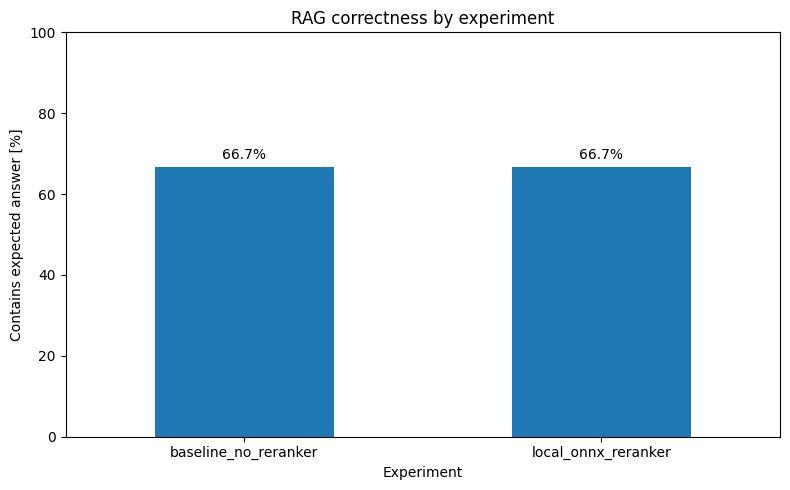

In [8]:
accuracy = summary.set_index("experiment")["accuracy_percent"]

plt.figure(figsize=(8, 5))
accuracy.plot(kind="bar")

plt.title("RAG correctness by experiment")
plt.ylabel("Contains expected answer [%]")
plt.xlabel("Experiment")
plt.ylim(0, 100)
plt.xticks(rotation=0)

for index, value in enumerate(accuracy):
    plt.text(index, value + 2, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.savefig(plots_dir / "contains_expected_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## latency avg_latency_ms chart

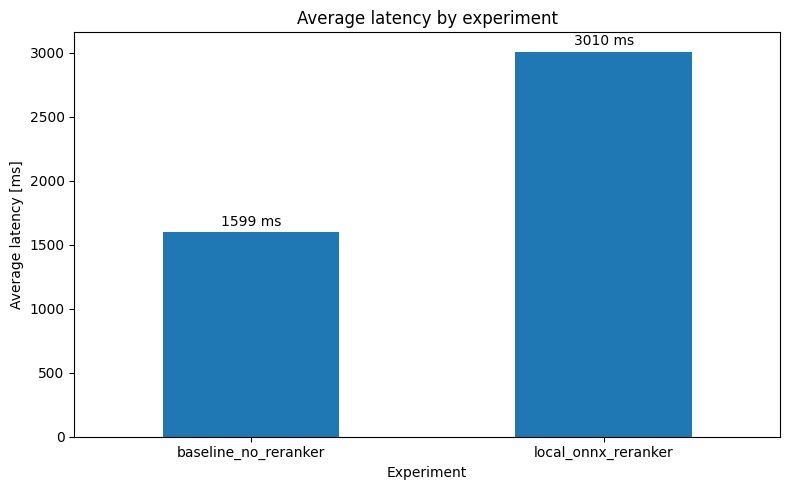

In [9]:
latency = summary.set_index("experiment")["avg_latency_ms"]

plt.figure(figsize=(8, 5))
latency.plot(kind="bar")

plt.title("Average latency by experiment")
plt.ylabel("Average latency [ms]")
plt.xlabel("Experiment")
plt.xticks(rotation=0)

for index, value in enumerate(latency):
    plt.text(index, value + 50, f"{value:.0f} ms", ha="center")

plt.tight_layout()
plt.savefig(plots_dir / "average_latency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## latency per requests chart

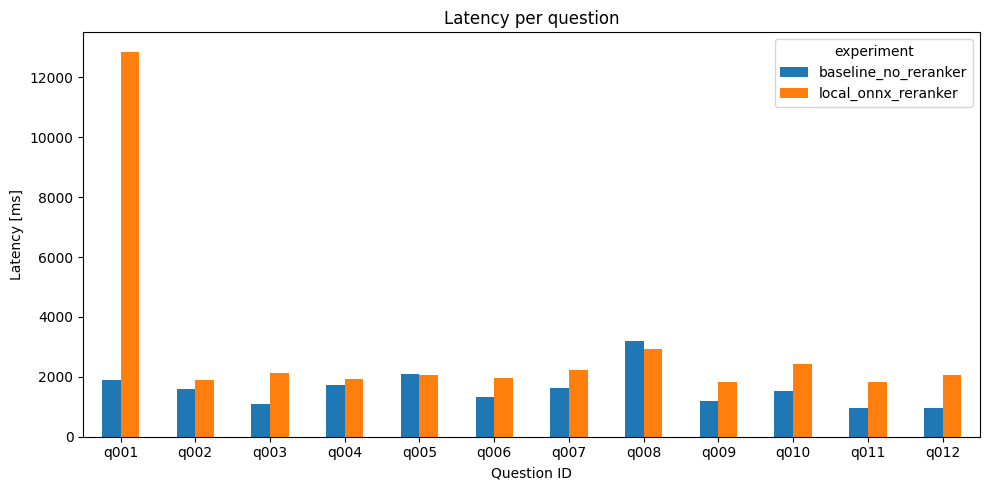

In [10]:
latency_per_question = df.pivot(
    index="question_id",
    columns="experiment",
    values="latency_ms"
)

latency_per_question

ax = latency_per_question.plot(kind="bar", figsize=(10, 5))

ax.set_title("Latency per question")
ax.set_ylabel("Latency [ms]")
ax.set_xlabel("Question ID")

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(plots_dir / "latency_per_question.png", dpi=150, bbox_inches="tight")
plt.show()

## correctness per request chart

<Figure size 1000x500 with 0 Axes>

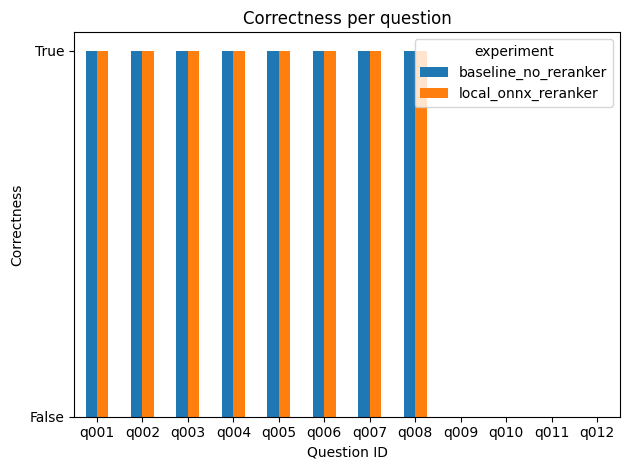

In [11]:
correctness_per_question = df.pivot(
    index="question_id",
    columns="experiment",
    values="contains_expected"
)

correctness_numeric = correctness_per_question.astype(int)

correctness_numeric

plt.figure(figsize=(10, 5))
correctness_numeric.plot(kind="bar")

plt.title("Correctness per question")
plt.ylabel("Correctness")
plt.xlabel("Question ID")
plt.yticks([0, 1], ["False", "True"])
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(plots_dir / "correctness_per_question.png", dpi=150, bbox_inches="tight")
plt.show()

## without outlier latency_ms chart

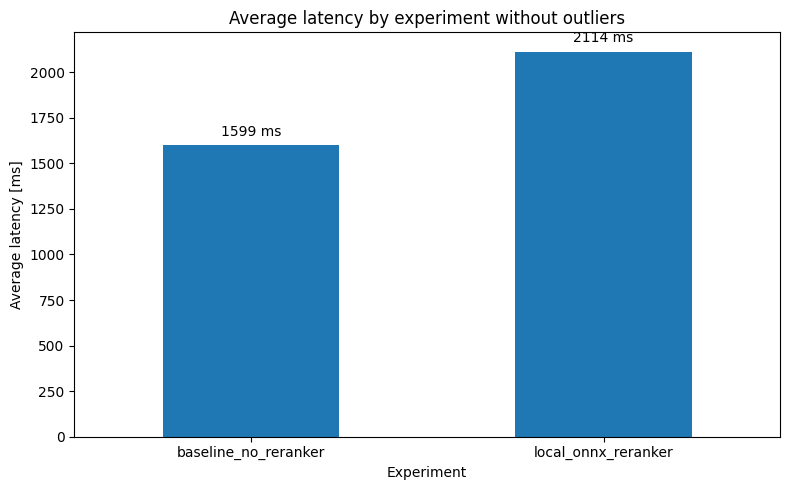

In [12]:
latency_threshold_ms = 5000

df_no_outliers = df[df["latency_ms"] <= latency_threshold_ms]

summary_no_outliers = (
    df_no_outliers.groupby("experiment")
    .agg(
        avg_latency_ms=("latency_ms", "mean"),
        median_latency_ms=("latency_ms", "median")
    )
    .reset_index()
)

summary_no_outliers

latency_no_outliers = summary_no_outliers.set_index("experiment")["avg_latency_ms"]

plt.figure(figsize=(8, 5))
latency_no_outliers.plot(kind="bar")

plt.title("Average latency by experiment without outliers")
plt.ylabel("Average latency [ms]")
plt.xlabel("Experiment")
plt.xticks(rotation=0)

for index, value in enumerate(latency_no_outliers):
    plt.text(index, value + 50, f"{value:.0f} ms", ha="center")

plt.tight_layout()
plt.savefig(plots_dir / "average_latency_without_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

## Initial observations

Both baseline vector retrieval and local ONNX reranking achieved the same simple `contains_expected` score on the synthetic benchmark.

The local reranker increased average latency, mainly because each query requires additional local ONNX inference over retrieved candidate chunks.

This benchmark is still too easy for reranking to show quality improvements. A larger multi-document dataset with more ambiguous or competing chunks is needed to evaluate reranking benefits more realistically.